# Lab Assignment: Generative AI

#### Lab team: teamCode

##### Name (member 1): firstName_1 lastName1_1 lastName1_2

##### Name (member 2): firstName_2 lastName2_1 lastName2_2

* Please include your full name at the beginning of all submitted files.
* Make sure the presentation is well-structured: the report will be evaluated not only for correctness, but also for clarity, conciseness, and completeness.
* Make use of figures and tables to summarize the results and illustrate the discussions.
* If external material is used, the sources must be cited. 
* Include references in APA format https://pitt.libguides.com/citationhelp/apa7. Lack or poorly formatted references can be penalized.
* A generative AI tool can be used for consultation. You must specify the tool used in your report.
* You are not allowed to use a generative AI tool to generate code.

Submit a single `.zip` file, whose name has the format `AA3_2024_2025_P02_teamCode_lastName1_lastName2.zip` 
The name must not include graphical accents, spaces, uppercase letters, or special characters.

For example: `AA3_2024_2025_P02_V03_munyoz_deLaRosa.zip`

This compressed file must include the following files:

* This Python notebook with the solutions of the exercises. The notebook should include only code snippets, figures, tables, derviations and explanations (with LaTex if necessary) in Markdown cells. Handwritten material can be included in the Python notebook as images. Functions should be defined in a separate `.py` file, not in the notebook.
* The necessary `.py` and addional files to ensure the Python notebook code can be executed sequentially without errors.
* A PDF file generated from the notebook (Export the notebook as an HTML file. Open the HTML file in a Browser and print it as a PDF file). 

Make sure that all the code cells can be executed squentially without errors (Kernel -> Restart & Run All). Exectution and formatting errors will be penalized.

The grade of this lab assignment is based on
* This submission (50 %).
* An individual in-class exam (50%).


Evaluation criteria:
* [6 points] Quality of the report (correctness, clarity, conciseness, completeness).
* [3 points] Quality of the code (correctness, adherence to a Python style guide -for instance, Google's-, comments, functional decomposition).
* [1 point]  References.                                                                   

## References:

1. Yang Song, Jascha Sohl-Dickstein, Diederik P. Kingma, Abhishek Kumar, Stefano Ermon and Ben Poole
"Score-Based Generative Modeling through Stochastic Differential Equations"
In International Conference on Learning Representations, 2021
https://arxiv.org/abs/2011.13456
2. H. Pan, Q. Zhou and L. J. Latecki, "SGUNET: Semantic Guided UNET For Thyroid Nodule Segmentation,"
2021 IEEE 18th International Symposium on Biomedical Imaging (ISBI), Nice, France, 2021, pp. 630-634 
https://ieeexplore.ieee.org/document/9434051
3. P. Vincent, “A connection between score matching and denoising autoencoders,”
Tech. Rep. 1358, Department of Computer Science and Operations Research, Uni-
versity of Montreal, 2010.
4. A. Hyv¨arinen, “Estimation of non-normalized statistical models by score matching,”
Journal of Machine Learning Research, vol. 6, no. 24, pp. 695–709, 2005.

## Exercise 1:  Generative AI based on diffusion models: Brownian motion 

In this exercise the training data is generated by injectiong noise using Brownian motion (variance exploding diffusion model).
The stochastic differencial equation (SDE) that characterizes this forward diffusion process is
$$
d\mathbf{x}(t) = \sigma^t d\mathbf{W}(t) 
$$

with $ \mathbf{x}(0) \sim p_0\left(\mathbf{x} \right)$, and  $\sigma > 0 $.
1. What is the distribution of $\mathbf{x}(t)$ assuming that $\mathbf{x}(0) = \mathbf{x}_0$ for arbitrary t?
  
   Since there is no drift term we only need to integrate the diffusion by the general formal solution of an SDE with Itô's form given the initial condition.
   $$
   \mathbf{x}(t) = \mathbf{x}_0 + \int_0^t \sigma^{s} dW(s)
   $$

   We know the Itô's solution follows a gaussian with $\mu = \mathbf{x}_0 $ but we need to calculate $\sigma^2(t)$ which in our case is:
$$
\sigma^2(t) = \int_0^t g^2(s)ds = \int_0^t \sigma^{2s} ds = \frac{\sigma^{2t} - 1}{2log\sigma}
$$

Finally we get: $$\mathbf{x}(t) \sim \mathcal{N}\!\left(\mathbf{x}_0,\ \frac{\sigma^{2t}-1}{2\ln\sigma}\,\mathbf{I}\right)$$

Note: An alternative approach is given by Song (2021) as referenced in our memory and is such as:

$$ \sigma^2(t) = \sigma_{\text{min}}(\frac{\sigma_{\text{max}}}{\sigma_{\text{min}}})^t \approx \sigma^{2t}$$

In this case we determine $\sigma$ by an heuristic manner that depends on the dataset

1. What is the SDE for the time-reversed process? 
   $$d\textbf{x} = -\sigma^{2t}\nabla_\textbf{x}\operatorname{log}p(\textbf{x})dt + \sigma^t dW$$
2. For the synthesis of new images
    1. In what interval is the reverse process SDE integrated?
    
    We need to integrate from the furthest moment of the forward process, in this case $t=T$ until the original moment $t=0$
    $$
    t \in [T, 0]
    $$
    2. From which distribution $\pi\left(\mathbf{x} \right)$ is the initial condition of the reverse SDE sampled?
    
    Note that we are in the reversed process so $x(T) = x_T$ and this is sampled from this distribution:

$$\mathbf{x}(T) \sim \mathcal{N}\!\left(\mathbf{0},\ \frac{\sigma^{2T}-1}{2\ln\sigma}\,\mathbf{I}\right)$$

### Exercise 1.1:  Training the model by weighted sum of denoising score matching objectives
1. Give the mathematical form and explain the cost function used in the training of the generative AI model.
$$ \ell(\boldsymbol{\theta}) = \frac{1}{N} \sum_{n=1}^N \left\| \sigma(t_n) \, s_{\theta}(\mathbf{x}(t_n), t_n) + \mathbf{z}_n\right\|_2^2
$$
This function is an evolution of the cost function stated by Aapo Hyvärine (2005) and further conclusions from Vincent (2011),  rewritten by Yang Song (2021) focused on noise detection. (note here we use loss/cost function indistinguishably). 

What this fucntion means intuintively is that our $ s_{\theta}(\mathbf{x}(t_n), t_n)$ in practice implemented as  U-net is going to try to predict the noise that we have previously injected at each corruption step. We achieve this because we know that $\nabla_{\mathbf{x}} \log p_{0t}\!\left(\mathbf{x}(t_n)\mid\mathbf{x}_0\right) = -\frac{\mathbf{z}_n}{\sigma(t_n)}$ and our prediction is $s_{\theta}(\mathbf{x}(t_n), t_n) \approx \nabla_{\mathbf{x}} \log p_t(\mathbf{x}(t_n))$ so we are essentially calculating with the norm $L_2$ the distance between the predicted score  $s_{\theta}$ ​and the true score $-\frac{\mathbf{z}_n}{\sigma(t_n)}$, which is known during training because we injected $\mathbf{z}_n$
ourselves.

2. Indicate what type of neural network is used to model the score, its inputs, outputs, and architecture.   

To model the score we use a **U-net** (Pan et al. (2021) and lecture notes)

**Inputs**:
- The image we have introduced noise to in our case $\mathbf{x}(t) \in \mathbb{R}^{64 \times 64 \times C}$ at corruption level $t$
- Time "t"

**Output**:
- The estimated score $s_{\theta}(\mathbf{x}(t), t) \in \mathbb{R}^{64 \times 64 \times C}$, 

**Architecture**:
- **Encoder**:Downsamples the resolution by convolutional blocks and max-pooling, incrementing the depth of the channels at each level
- **Decoder**: Recovers the original resolution by transposed convolutions
- **Skip-connections**: Connects the charateristic maps of each level of the encoder to the decoder

3. Explain how time is input in the neural network model for the time-dependent score function using random Fourier features.
   Time is input by random Fourier feature embeddings
4. Illustrate how to train a model to generate handwritten digits for the MNIST dataset using the Brownian motion diffusion model.
This first block of code should run in less than 5 minutes.

In [5]:
import torch
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Importamos tus archivos originales y la lógica del ejercicio
import diffusion_process as dfp
import diffusion_utilities as utils
import solucion_ejercicio1 as sol

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Carga de datos MNIST (Subconjunto para entrenamiento < 5 min)
transform = transforms.Compose([transforms.ToTensor()])
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
subset = torch.utils.data.Subset(dataset, range(2000)) # Ajustado para velocidad
train_loader = DataLoader(subset, batch_size=64, shuffle=True)

# Instanciamos el proceso de difusión
proceso = dfp.GaussianDiffussionProcess(
    drift_coefficient=sol.bm_drift_coefficient,
    diffusion_coefficient=sol.bm_diffusion_coefficient,
    mu_t=sol.bm_mu_t,
    sigma_t=sol.bm_sigma_t
)

# Cargamos tu ScoreNet profesional
model = sol.crear_score_model(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [6]:
epochs = 10
loss_history = []

model.train()
print(f"Entrenando en {device}...")

for epoch in range(epochs):
    epoch_loss = 0
    for images, _ in train_loader:
        images = images.to(device)
        
        # Cálculo de pérdida usando tu librería diffusion_process.py
        loss = proceso.loss_function(model, x_0=images)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

# Guardar el modelo entrenado
torch.save(model.state_dict(), 'mnist_brownian_trained.pth')

Entrenando en cuda...
Epoch 1/10 | Loss: 893.3042
Epoch 2/10 | Loss: 278.1555
Epoch 3/10 | Loss: 189.6058
Epoch 4/10 | Loss: 148.4579
Epoch 5/10 | Loss: 123.0268
Epoch 6/10 | Loss: 108.1412
Epoch 7/10 | Loss: 95.1482
Epoch 8/10 | Loss: 85.6993
Epoch 9/10 | Loss: 79.1942
Epoch 10/10 | Loss: 73.9887


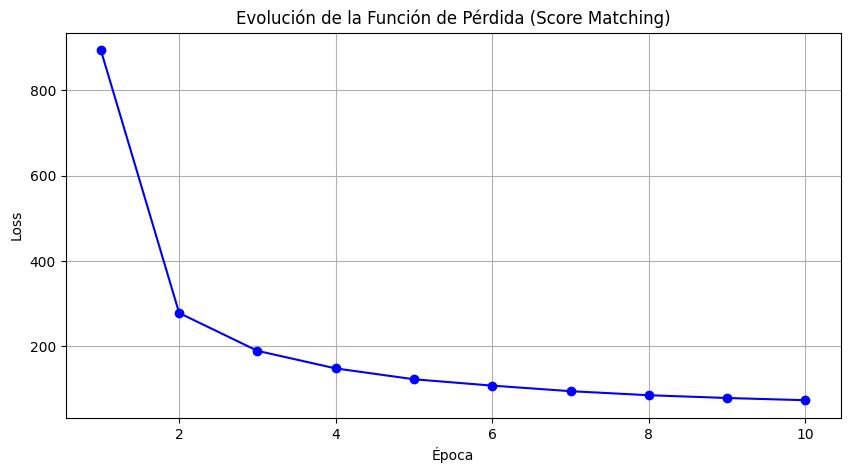

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o', color='b', linestyle='-')
plt.title('Evolución de la Función de Pérdida (Score Matching)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

### Exercise 1.2: Generation using the Euler-Maruyama integrator
Use a model that you have previously trained (not the one in the previous exercise) high-quality model to generate some samples using the Euler-Maruyama integrator.

In [2]:
import torch
from functools import partial
from score_model_digits_color import ScoreNet # O tu clase de score model
import solucion_ejercicio2 as sol

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

score_model = ScoreNet(marginal_prob_std=partial(sol.bm_sigma_t, sigma=sol.SIGMA_DEFAULT))

# 2. Cargar Checkpoint
n_epochs = 500
try:
    path = f'digit_6_{n_epochs}_epochs.pth'
    check_point = torch.load(path, map_location=device)
    score_model.load_state_dict(check_point)
    score_model.to(device).eval()
except FileNotFoundError:
    print("Error: No se encontró el archivo de pesos.")

# 3. Generar muestras usando la función del archivo .py
n_images = 5
synthetic_images_t = sol.generar_muestras_ejercicio(score_model, n_images, device=device)

print(f"Tipo de salida: {type(synthetic_images_t)}")
print(f"Dimensiones finales: {synthetic_images_t.shape}")



C:\Users\lucan\AppData\Local\Temp\ipykernel_51948\2758095012.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  check_point = torch.load(path, map_location=device)


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

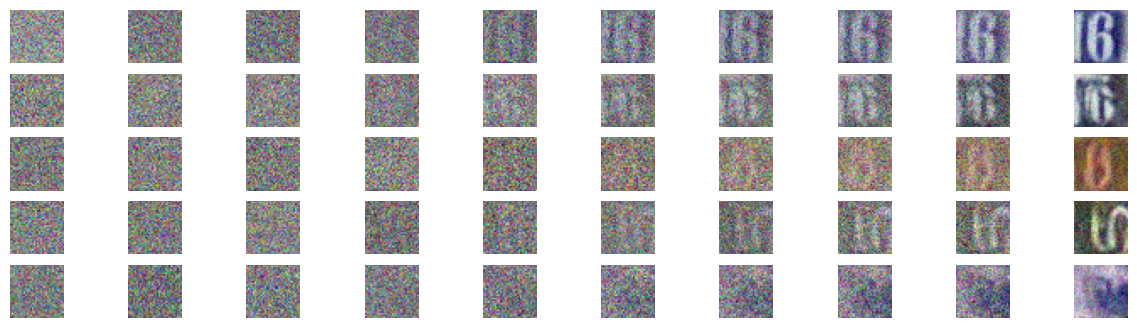

In [11]:
from diffusion_utilities import plot_image_evolution_rgb

_ = plot_image_evolution_rgb(
    
    images=synthetic_images_t,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

### Exercise 1.3: Generation using a probability flow ODE.
1. Explain what is the Fokker-Planck equation and in what way is it related to an SDE.
2. Explain how the probability flow ODE can be used to generate samples from  $p_0\left(\mathbf{x} \right)$.
2. Implement and illustrate the use of this method to generate synthetic images of handwritten digits. 
3. Indicate how to use this scheme to compute likelihoods. Implement this functionality and illustrate its use.

## Exercise 2:  Generative AI based on diffusion models: The Ornstein-Uhlenbeck process

In this exercise, the training data is generated by injecting noise using Brownian motion (variance preserving diffusion model).
The stochastic differencial equation (SDE) that characterizes this forward diffusion process is
$$
d\mathbf{x}(t) = - \frac{1}{2} \beta(t) \mathbf{x}(t) + \sqrt{\beta(t)} d\mathbf{W}(t) 
$$
with $ \mathbf{x}(0) \sim p_0\left(\mathbf{x} \right)$
1. What is the distribution of $\mathbf{x}(t)$ assuming that $\mathbf{x}(0) = \mathbf{x}_0$ for arbitrary t?
2. What is the SDE for the time-reversed process? 
3. For the synthesis of new images
        1. In what interval is the reverse process SDE integrated?
        2. From which distribution $\pi\left(\mathbf{x} \right)$ is the initial condition of the reverse SDE sampled? 

### Exercise 2.1: Training and generation of images using the OU process and different noise schedules
1. Using the linear noise schedule.
2. Using the cosine noise schedule.
3. Using a third noise schedule of your choice.

## Exercise 3:  Evaluation of the quality of the generated images
1. Describe, and compare the characteristics, advantages, and disadvantages of the following measures of quality for generative IA models for images:
    1. The negative log-likelihood (NLL).
    2. Bits per dimension (BPD). 
    3. Fréchet Inception Distance (FID).
    4. A third measure of your choice.
2. Compare using BPD the different diffusion models (Brownian motion, Ornstein-Uhlenbeck), noising schedules (linear, cosine, etc.), and sampling strategies (SDE, ODE) implemented.